# Machine learning over sets 
## Yoav Ram

This notebook compares three architectures for classifying **unordered sets** of items:
1. **Flattened MLP** — concatenate all items into one vector
2. **Deep Sets** — shared per-item network with sum pooling
3. **Set Transformer** — self-attention over items with mean pooling

We use the [Poker Hand dataset](https://archive.ics.uci.edu/dataset/158/poker+hand) as a running example: each hand is a set of 5 cards, and the task is to classify the hand type (pair, flush, straight, etc.).

The main goal is to understand how **inductive biases** — particularly **permutation invariance** — affect learning on set-structured data, and to motivate the move to sequence models in later notebooks.

In [1]:
%matplotlib inline
import matplotlib.pyplot as plt

import os
import jax
import jax.numpy as jnp
import numpy as np
import optax

print('jax', jax.__version__, jax.default_backend())

key = jax.random.key(2)

jax 0.5.3 cpu


# Problem 

A poker hand is a set of 5 cards. Each card has a **suit** (Hearts, Spades, Diamonds, Clubs) and a **rank** (Ace through King). The task is to classify the hand into one of 10 types:

| Class | Hand type       | Example             |
|-------|----------------|---------------------|
| 0     | Nothing         | 2♠ 5♦ 8♣ J♥ K♦     |
| 1     | One pair        | 3♠ 3♦ 7♣ J♥ K♦     |
| 2     | Two pairs       | 3♠ 3♦ 7♣ 7♥ K♦     |
| 3     | Three of a kind | 3♠ 3♦ 3♣ J♥ K♦     |
| 4     | Straight        | 5♠ 6♦ 7♣ 8♥ 9♦     |
| 5     | Flush           | 2♠ 5♠ 8♠ J♠ K♠     |
| 6     | Full house      | 3♠ 3♦ 3♣ 7♥ 7♦     |
| 7     | Four of a kind  | 3♠ 3♦ 3♣ 3♥ K♦     |
| 8     | Straight flush  | 5♠ 6♠ 7♠ 8♠ 9♠     |
| 9     | Royal flush     | 10♠ J♠ Q♠ K♠ A♠    |

This is a natural **set classification** problem: the order of cards in a hand does not matter — {3♠, 7♦, K♣, 2♥, 9♠} is the same hand regardless of how the cards are arranged.

# Data

The [Poker Hand dataset](https://archive.ics.uci.edu/dataset/158/poker+hand) from the UCI Machine Learning Repository contains over 1 million hands. Each hand is described by 10 attributes (suit and rank for each of 5 cards) and a class label.

In [2]:
X_train = np.loadtxt(os.path.join('data', 'poker-hand-training-true.data'), delimiter=',', dtype=int)
X_test = np.loadtxt(os.path.join('data', 'poker-hand-testing.data'), delimiter=',', dtype=int)
X = np.concatenate([X_train, X_test], axis=0)

print(f"Total hands: {len(X):,}")
print(f"Columns: {X.shape[1]} (5 cards × 2 attributes + 1 label)")

Total hands: 1,025,010
Columns: 11 (5 cards × 2 attributes + 1 label)


In [3]:
# Columns: S1, C1, S2, C2, S3, C3, S4, C4, S5, C5, CLASS
suits = X[:, [0, 2, 4, 6, 8]] - 1    # (N, 5), values 0-3
ranks = X[:, [1, 3, 5, 7, 9]] - 1    # (N, 5), values 0-12
card_idx = suits * 13 + ranks           # (N, 5), values 0-51
Y = X[:, 10]                      # (N,),   values 0-9
X = np.eye(52, dtype=np.float32)[card_idx]  # (N, 5, 52) one-hot per card


hand_names = [
    'Nothing', 'One pair', 'Two pairs', 'Three of a kind', 'Straight',
    'Flush', 'Full house', 'Four of a kind', 'Straight flush', 'Royal flush'
]
n_classes = len(hand_names)

print("Class distribution:")
for c in range(n_classes):
    count = (Y == c).sum()
    print(f"  {c}: {hand_names[c]:<20s} {count:>8,d} ({100 * count / len(Y):.2f}%)")

Class distribution:
  0: Nothing               513,702 (50.12%)
  1: One pair              433,097 (42.25%)
  2: Two pairs              48,828 (4.76%)
  3: Three of a kind        21,634 (2.11%)
  4: Straight                3,978 (0.39%)
  5: Flush                   2,050 (0.20%)
  6: Full house              1,460 (0.14%)
  7: Four of a kind            236 (0.02%)
  8: Straight flush             17 (0.00%)
  9: Royal flush                 8 (0.00%)


In [4]:
# Shuffle and split: 80% train, 10% val, 10% test
rng = np.random.default_rng(172)
perm = rng.permutation(len(Y))
X, Y = X[perm], Y[perm]

n = len(Y)
n_train = int(0.8 * n)
n_val = int(0.1 * n)

X_train      = jnp.array(X[:n_train])
Y_train = jnp.array(Y[:n_train])

X_val      = jnp.array(X[n_train:n_train + n_val])
Y_val = jnp.array(Y[n_train:n_train + n_val])

X_test      = jnp.array(X[n_train + n_val:])
Y_test = jnp.array(Y[n_train + n_val:])

print(f"Train: {len(Y_train):,}  Val: {len(Y_val):,}  Test: {len(Y_test):,}")

Train: 820,008  Val: 102,501  Test: 102,501


# Embedding

Each card is identified by its suit (0–3) and rank (0–12), giving 4 × 13 = 52 unique cards. 

We represent each card as a one-hot vector of size 52 and project it through a **learned embedding matrix** to get a dense vector of size $d$:
$$\mathbf{e}_i = W_{\text{emb}} \cdot \text{onehot}(s_i \times 13 + r_i)$$
This is equivalent to a lookup in a $(52 \times d)$ embedding table — one learned vector per card. Since the input is already one-hot encoded, the embedding is a simple matrix multiplication.

In [5]:
d_card = 16  # card embedding dimension
n_cards = 5
n_vocab = 52  # 4 suits × 13 ranks

def embed(params, x):
    """
    x : (B, 5, 52) one-hot encoded cards
    Returns: (B, 5, d_card)
    """
    return x @ params['emb']              # (B, 5, d_card)

# Training 

This is a classification problem, so we use cross entropy loss function.
We also measure accuracy as an evaluation metric.

In [6]:
def cross_entropy_loss(logits, targets): #logy_hat/(1-yhat), y
    log_probs = jax.nn.log_softmax(logits, axis=-1)
    return -jnp.mean(log_probs[jnp.arange(targets.shape[0]), targets])

def accuracy(params, model, x, labels, batch_size=4096):
    """Compute accuracy in batches."""
    n = len(labels)
    correct = 0
    for i in range(0, n, batch_size):
        logits = model(params, x[i:i + batch_size])
        preds = jnp.argmax(logits, axis=-1)
        correct += jnp.sum(preds == labels[i:i + batch_size])
    return float(correct / n)

We are going to use the same train function for all three models.

In our framework, a model is specified by it's feed forward function (`model`) and it's parameters are initialized using `init_fn`.

The `train` function defines the gradient descent step as a single computation of the gradients and loss. This is then used to train the model in a training loop of `n_steps` iterations. Once every 1,000 iterations, the model is evaluated on the validation set.

In [7]:
def train(name, init_fn, model, n_steps=10_000, batch_size=256, lr=1e-3, seed=0):
    """Train a model and return params + training history."""
    key = jax.random.key(seed)
    key, subkey = jax.random.split(key)
    params = init_fn(subkey)
    print(f"{name}: {count_params(params):,} parameters")

    optimizer = optax.adamw(lr, weight_decay=1e-4)
    opt_state = optimizer.init(params)

    @jax.jit
    def step(params, opt_state, x, y):
        def loss_fn(p):
            return cross_entropy_loss(model(p, x), y)
        loss, grads = jax.value_and_grad(loss_fn)(params)
        updates, opt_state_new = optimizer.update(grads, opt_state, params)
        return optax.apply_updates(params, updates), opt_state_new, loss

    train_losses = []
    val_log = []
    log_every = 1000
    n_train = len(Y_train)

    val_n = min(5000, len(Y_val))
    x_val, y_val = X_val[:val_n], Y_val[:val_n]

    for i in range(1, n_steps + 1):
        key, subkey = jax.random.split(key)
        idx = jax.random.randint(subkey, (batch_size,), 0, n_train)
        params, opt_state, loss = step(
            params, opt_state, X_train[idx], Y_train[idx]
        )
        train_losses.append(float(loss))

        if i % log_every == 0:
            logits_val = model(params, x_val)
            loss_val = float(cross_entropy_loss(logits_val, y_val))
            acc_val = float(jnp.mean(jnp.argmax(logits_val, axis=-1) == y_val))
            val_log.append((i, loss_val, acc_val))
            print(f"  step {i:5d} | train loss={train_losses[-1]:.4f} | val loss={loss_val:.4f} | val acc={acc_val:.3f}")

    return params, train_losses, val_log

In [8]:
def plot_training(name, train_losses, val_log):
    fig, axes = plt.subplots(1, 2, figsize=(10, 3))
    axes[0].plot(train_losses, alpha=0.3)
    if val_log:
        steps, vl, va = zip(*val_log)
        axes[0].plot(steps, vl, 'o-', label='val')
    axes[0].set_xlabel('Step'); axes[0].set_ylabel('Cross-entropy loss')
    axes[0].set_title(f'{name} — Loss'); axes[0].legend()

    if val_log:
        axes[1].plot(steps, [100 * a for a in va], 'o-', color='green')
        axes[1].set_xlabel('Step'); axes[1].set_ylabel('Accuracy (%)')
        axes[1].set_title(f'{name} — Val Accuracy')

    plt.tight_layout(); plt.show()

In [9]:
def count_params(pytree):
    leaves = jax.tree_util.tree_leaves(pytree)
    return sum(x.size for x in leaves if hasattr(x, 'size'))

# Model 1: Flattened MLP

The simplest approach: flatten all 5 card embeddings into a single vector and pass it through a standard MLP.

$$x_i = [e_{i,1} , e_{i,2} , e_{i,3} , e_{i,4} , e_{i,5}]$$
$$h_i = \text{ReLU}(W_1 x_i + b_1)$$
$$\hat{y}_i = \text{softmax}\big(W_2 h_i + b_2\big)$$

This approach has two key limitations:
- **Fixed input size**: the model is hardcoded to exactly 5 cards.
- **Not permutation-invariant**: swapping two cards in the input changes the flattened vector and can change the output, even though the hand is the same. The model must learn to be approximately invariant from data alone.

In [11]:
d_mlp = 48

def init_mlp(key):
    keys = jax.random.split(key, 3)
    scale = 0.1
    return {
        'emb': jax.random.normal(keys[0], (n_vocab, d_card)) * scale,
        'W1': jax.random.normal(keys[1], (n_cards * d_card, d_mlp)) * scale,
        'b1': jnp.zeros(d_mlp),
        'W2': jax.random.normal(keys[2], (d_mlp, n_classes)) * scale,
        'b2': jnp.zeros(n_classes),
    }

def mlp(params, x):
    x = embed(params, x)                         # (B, 5, d_card)
    x = x.reshape(x.shape[0], -1)                # (B, 5 * d_card)
    x = jax.nn.relu(x @ params['W1'] + params['b1'])
    return x @ params['W2'] + params['b2']

Flattened MLP: 5,210 parameters
  step  1000 | train loss=1.0387 | val loss=0.9865 | val acc=0.487
  step  2000 | train loss=0.8908 | val loss=0.9524 | val acc=0.555
  step  3000 | train loss=0.9501 | val loss=0.9265 | val acc=0.565
  step  4000 | train loss=0.9079 | val loss=0.9084 | val acc=0.593
  step  5000 | train loss=0.8473 | val loss=0.8981 | val acc=0.594
  step  6000 | train loss=0.8327 | val loss=0.8912 | val acc=0.596
  step  7000 | train loss=0.8261 | val loss=0.8824 | val acc=0.599
  step  8000 | train loss=0.8788 | val loss=0.8766 | val acc=0.605
  step  9000 | train loss=0.8798 | val loss=0.8559 | val acc=0.611
  step 10000 | train loss=0.7707 | val loss=0.8272 | val acc=0.632
  step 11000 | train loss=0.9170 | val loss=0.8089 | val acc=0.635
  step 12000 | train loss=0.7756 | val loss=0.7955 | val acc=0.643
  step 13000 | train loss=0.8107 | val loss=0.7831 | val acc=0.652
  step 14000 | train loss=0.7993 | val loss=0.7734 | val acc=0.659
  step 15000 | train loss=0.78

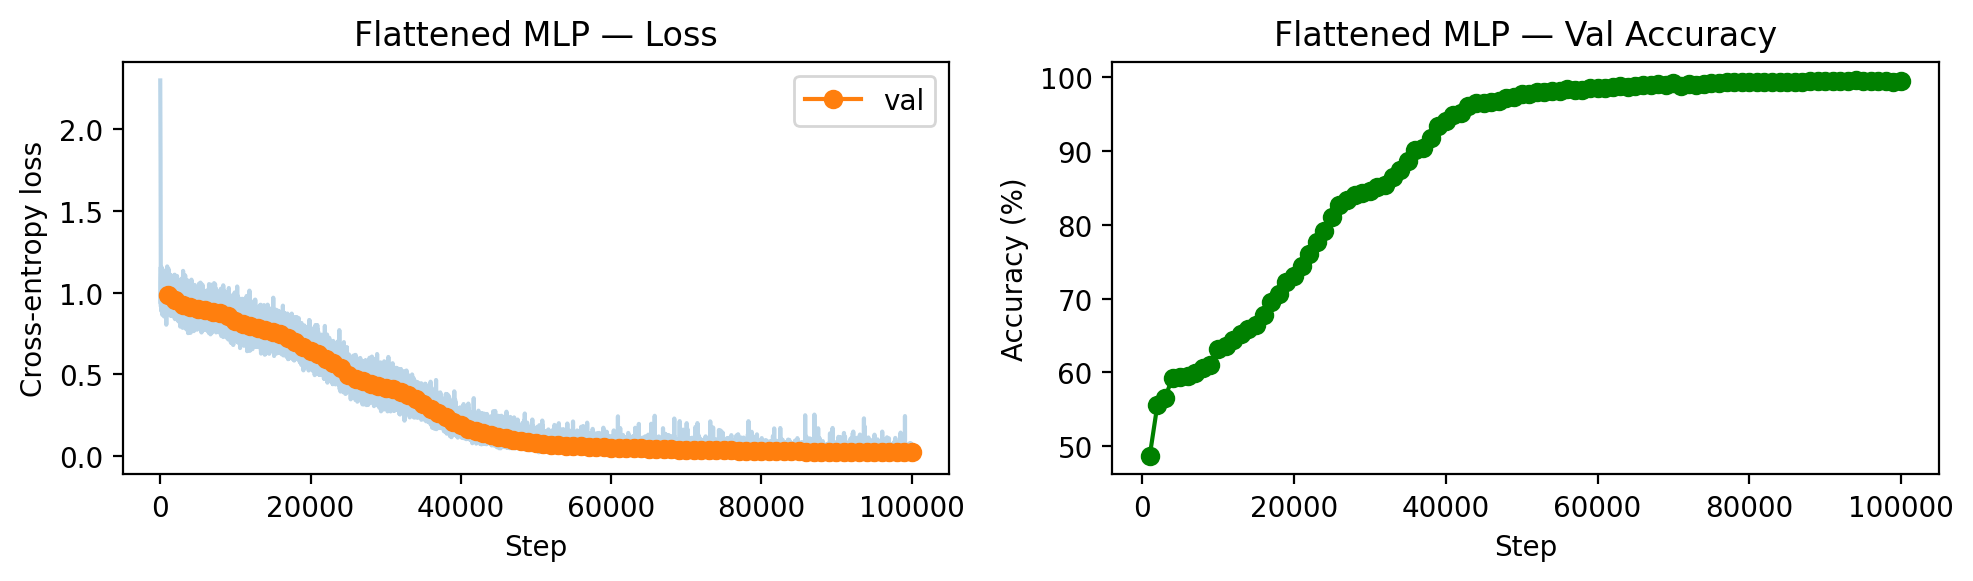

CPU times: user 1min 11s, sys: 12 s, total: 1min 23s
Wall time: 57.3 s


  step  5000 | train loss=0.8475 | val loss=0.8981 | val acc=0.593


  step  6000 | train loss=0.8329 | val loss=0.8911 | val acc=0.596


  step  7000 | train loss=0.8266 | val loss=0.8822 | val acc=0.599


  step  8000 | train loss=0.8774 | val loss=0.8766 | val acc=0.603


...

  step 26000 | train loss=0.6685 | val loss=0.5975 | val acc=0.766


  step 27000 | train loss=0.5514 | val loss=0.5797 | val acc=0.774


  step 28000 | train loss=0.5064 | val loss=0.5623 | val acc=0.782


  step 29000 | train loss=0.4640 | val loss=0.5387 | val acc=0.793


  step 30000 | train loss=0.5063 | val loss=0.5259 | val acc=0.797


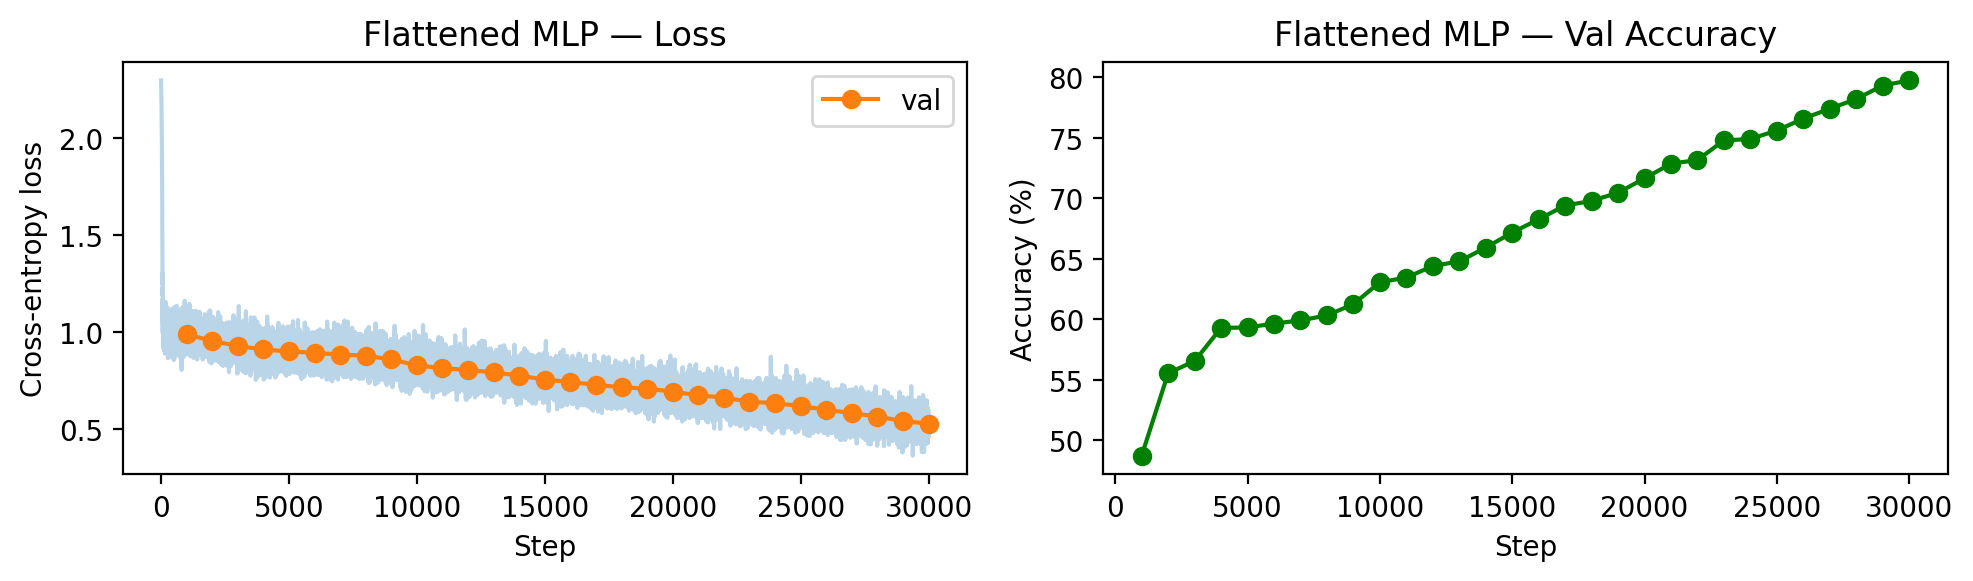

CPU times: user 21.9 s, sys: 1.44 s, total: 23.3 s
Wall time: 18.7 s


In [12]:
%%time
mlp_params, mlp_losses, mlp_val = train('Flattened MLP', init_mlp, mlp, n_steps=100_000)
plot_training('Flattened MLP', mlp_losses, mlp_val)

### Permutation sensitivity

Since the MLP concatenates cards in a fixed order, permuting the cards changes the input vector and can change the prediction. We verify this empirically: take a batch of hands, randomly shuffle the card order, and check how many predictions change.

In [14]:
key, subkey = jax.random.split(key)
idx = jax.random.randint(subkey, (1000,), 0, len(Y_test))
x_orig = X_test[idx]

key, subkey = jax.random.split(key)
perm = jax.random.permutation(subkey, 5)
x_perm = x_orig[:, perm]

pred_orig = jnp.argmax(mlp(mlp_params, x_orig), axis=-1)
pred_perm = jnp.argmax(mlp(mlp_params, x_perm), axis=-1)
changed = float(jnp.mean(pred_orig != pred_perm))
print(f"MLP: {100 * changed:.1f}% of predictions changed after permuting card order")

MLP: 0.3% of predictions changed after permuting card order


# Model 2: Deep Sets

[Deep Sets](https://arxiv.org/abs/1703.06114) (Zaheer et al., 2017) is the simplest architecture that is **permutation-invariant by construction**.

Apply a shared network to each element independently, **sum** the results, then apply a second network:

$$x_{i,j} = \text{ReLU}(W_1 e_{i,j} + b_1)$$
$$z_{i,j} = \text{ReLU}(W_2 x_{i,j} + b_2)$$
$$\tilde z_i = \sum_{j=1}^5 z_{i,j}$$
$$h_i = \text{ReLU}\!\left(W_3 \tilde z_i + b_3\right)$$
$$\hat{y} = \text{softmax}\!\left(W_4 h_i + b_4\right)$$

Since addition is commutative, the output is the same regardless of the order of inputs.

$W_1$ and $W_2$ are shared across all cards — they transform each card independently. After sum-pooling, $W_3$ and $W_4$ classify the aggregated representation. Zaheer et al. proved that any permutation-invariant function on a finite set can be decomposed into this form, making Deep Sets a universal approximator for set functions.

In [18]:
d_ds = 40

def init_deep_sets(key):
    keys = jax.random.split(key, 5)
    scale = 0.2
    return {
        'emb': jax.random.normal(keys[0], (n_vocab, d_card)) * scale,
        # Per-card transformation (two layers)
        'W1': jax.random.normal(keys[1], (d_card, d_ds)) * scale,
        'b1': jnp.zeros(d_ds),
        'W2': jax.random.normal(keys[2], (d_ds, d_ds)) * scale,
        'b2': jnp.zeros(d_ds),
        # Post-pool classifier
        'W3': jax.random.normal(keys[3], (d_ds, d_ds)) * scale,
        'b3': jnp.zeros(d_ds),
        'W4': jax.random.normal(keys[4], (d_ds, n_classes)) * scale,
        'b4': jnp.zeros(n_classes),
    }

def deep_sets(params, x):
    x = embed(params, x)                                    # (B, 5, d_card)
    x = jax.nn.relu(x @ params['W1'] + params['b1'])       # (B, 5, d_ds)
    x = jax.nn.relu(x @ params['W2'] + params['b2'])       # (B, 5, d_ds)
    x = x.sum(axis=1)                                       # (B, d_ds)
    x = jax.nn.relu(x @ params['W3'] + params['b3'])       # (B, d_ds)
    return x @ params['W4'] + params['b4']                  # (B, n_classes)

Deep Sets: 5,202 parameters
  step  1000 | train loss=0.8718 | val loss=0.8101 | val acc=0.654
  step  2000 | train loss=0.6618 | val loss=0.7664 | val acc=0.665
  step  3000 | train loss=0.7288 | val loss=0.7239 | val acc=0.685
  step  4000 | train loss=0.7371 | val loss=0.6819 | val acc=0.710
  step  5000 | train loss=0.4928 | val loss=0.6128 | val acc=0.732
  step  6000 | train loss=0.5588 | val loss=0.5115 | val acc=0.781
  step  7000 | train loss=0.4929 | val loss=0.4802 | val acc=0.798
  step  8000 | train loss=0.4603 | val loss=0.4597 | val acc=0.801
  step  9000 | train loss=0.5133 | val loss=0.4548 | val acc=0.798
  step 10000 | train loss=0.4302 | val loss=0.4421 | val acc=0.807
  step 11000 | train loss=0.5060 | val loss=0.4350 | val acc=0.813
  step 12000 | train loss=0.3579 | val loss=0.3850 | val acc=0.824
  step 13000 | train loss=0.3748 | val loss=0.3791 | val acc=0.832
  step 14000 | train loss=0.3717 | val loss=0.3737 | val acc=0.839
  step 15000 | train loss=0.4079 |

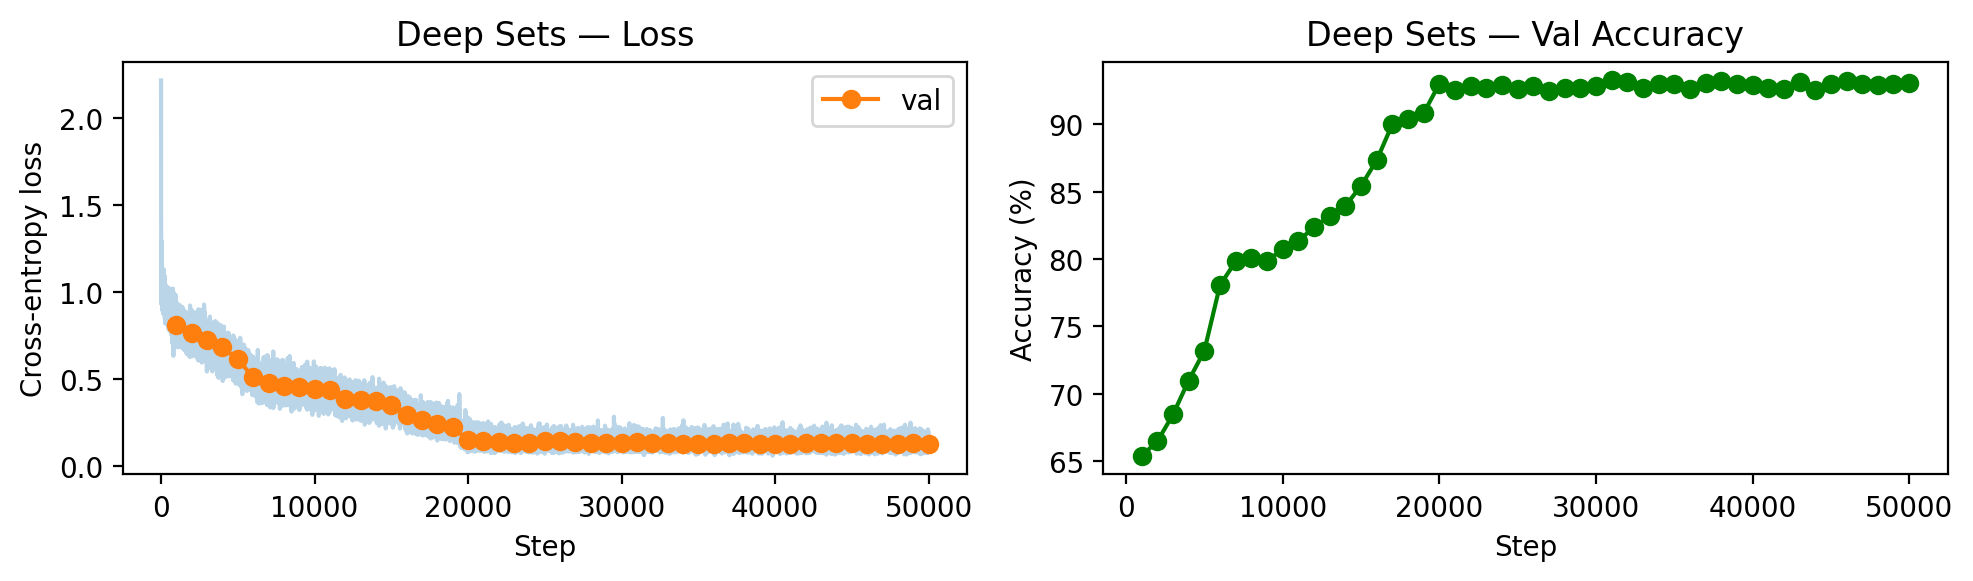

CPU times: user 57.3 s, sys: 14 s, total: 1min 11s
Wall time: 42.1 s


  step  3000 | train loss=0.7119 | val loss=0.7103 | val acc=0.694


  step  4000 | train loss=0.7363 | val loss=0.6699 | val acc=0.712


  step  5000 | train loss=0.5272 | val loss=0.6492 | val acc=0.722


  step  6000 | train loss=0.6052 | val loss=0.5837 | val acc=0.742


...

  step 26000 | train loss=0.2892 | val loss=0.3415 | val acc=0.848


  step 27000 | train loss=0.2476 | val loss=0.3416 | val acc=0.851


  step 28000 | train loss=0.2879 | val loss=0.3413 | val acc=0.849


  step 29000 | train loss=0.2380 | val loss=0.2543 | val acc=0.896


  step 30000 | train loss=0.2302 | val loss=0.2446 | val acc=0.897


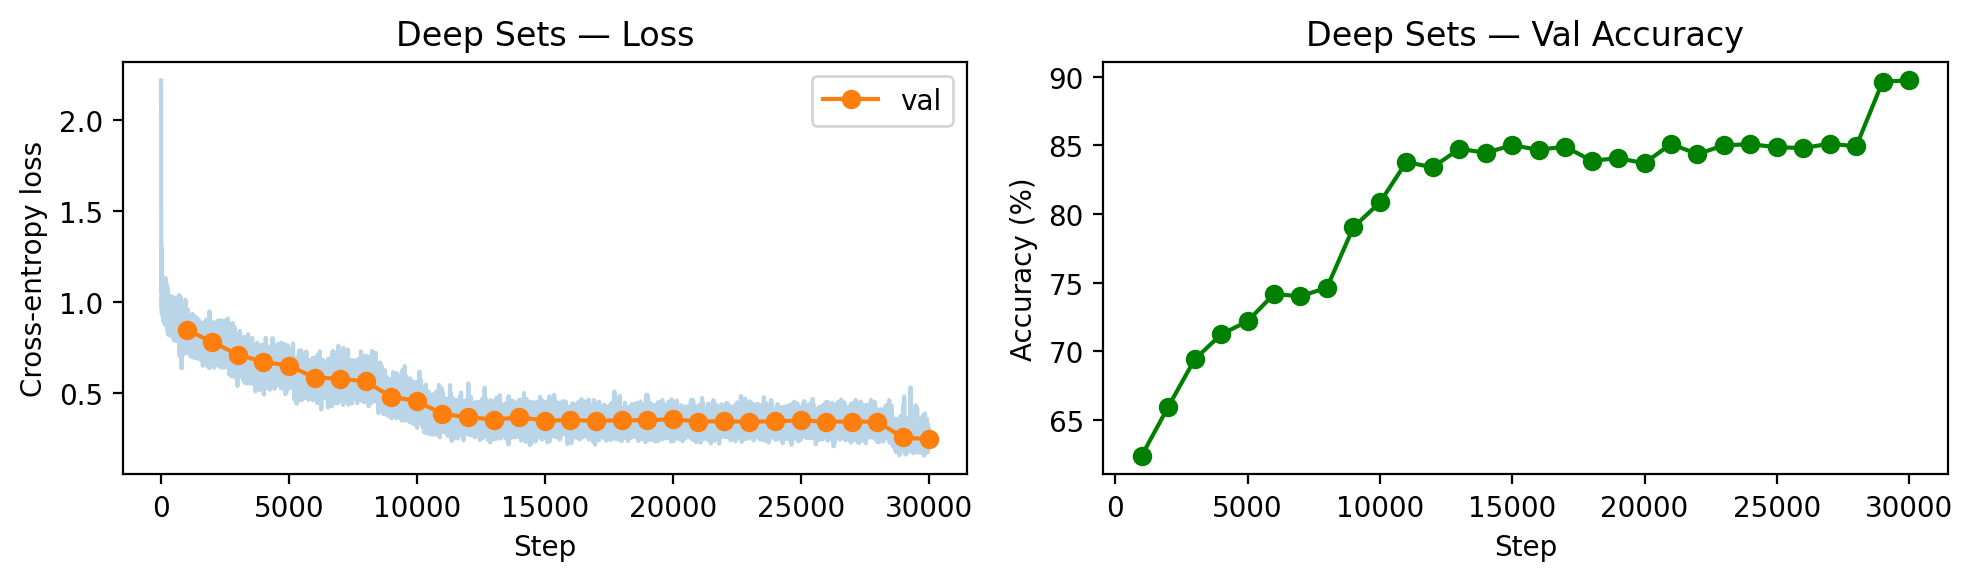

CPU times: user 32.1 s, sys: 5.43 s, total: 37.5 s
Wall time: 26.5 s


In [19]:
%%time
ds_params, ds_losses, ds_val = train('Deep Sets', init_deep_sets, deep_sets, n_steps=50_000, lr=3e-3)
plot_training('Deep Sets', ds_losses, ds_val)

In [20]:
pred_orig = jnp.argmax(deep_sets(ds_params, x_orig), axis=-1)
pred_perm = jnp.argmax(deep_sets(ds_params, x_perm), axis=-1)
changed = float(jnp.mean(pred_orig != pred_perm))
print(f"Deep Sets: {100 * changed:.1f}% of predictions changed after permuting card order")

Deep Sets: 0.0% of predictions changed after permuting card order


# Model 3: Set Transformer

The [Set Transformer](https://arxiv.org/abs/1810.00825) (Lee et al., 2019) extends Deep Sets by adding **self-attention** between set elements before pooling. This allows the model to capture **interactions between cards** — for example, noticing that two cards share the same suit (relevant for flushes) or that ranks form a consecutive sequence (relevant for straights).

## Self-attention

For each card $e_i$ in the input set $\{e_1,e_2,e_3,e_4,e_5\}$, we compute **query**, **key**, and **value** vectors:
$$q_i = W^q x_i$$
$$k_i = W^k x_i$$
$$v_i = W^v x_i$$

The **attention weight** of card $i$ to card $j$ is:
$$
w_{i,j} = \text{softmax}_j\left(\frac{q_i \cdot k_j}{\sqrt{d_k}}\right)
$$
where $d_k$ is the dimension of the key and query vectors, and $d_v$ is the dimension of the value vector.

The output for card $i$ is a weighted sum of values: 
$$$z_i = \sum_j w_{ij} v_j$$

Self-attention is **permutation-equivariant**: permuting the input cards produces the same permutation of the output.
After mean-pooling over cards, the full model is **permutation-invariant**.

In **multi-head** attention, we use multiple heads that attend independently, each producing a vector of dimension $d_v/n_{\text{heads}}$, then concatenate their outputs to a vector of dimensions $d_v$. This allows the model to attend to different types of relationships simultaneously.

In [37]:
def self_attention(x, W_q, W_k, W_v, W_o, n_heads):
    n_batch, n_cards, d_model = x.shape
    d_head = d_model // n_heads
    
    Q = (x @ W_q) # (n_batch, n_cards, d_model)
    K = (x @ W_k)
    V = (x @ W_v)

    # reshape to (n_batch, n_heads, n_cards, d_head)
    Q = Q.reshape(n_batch, n_cards, n_heads, d_head).transpose(0, 2, 1, 3)
    K = K.reshape(n_batch, n_cards, n_heads, d_head).transpose(0, 2, 1, 3)
    V = V.reshape(n_batch, n_cards, n_heads, d_head).transpose(0, 2, 1, 3)

    # attention weights
    w = (Q @ K.transpose(0, 1, 3, 2)) / jnp.sqrt(d_head)
    w = jax.nn.softmax(w, axis=-1)
    
    # weighted sum of values
    z = (w @ V)
    # concatenate heads
    z = z.transpose(0, 2, 1, 3).reshape(n_batch, n_cards, d_model)
    
    return z @ W_o

Thet ransformer uses **layer normalization** and **residual connections** around each sub-layer.

## Residual connections
Each Transformer block is built from sub-layers such as self-attention and a position-wise feed-forward network to processes the contextual embeddings produced by the self-attention heads.

Instead of replacing the input representation entirely, each sub-layer is wrapped in a **residual/skip connection**:
$$
x \mapsto x + \mathrm{Sublayer}(x).
$$

This means the sub-layer only has to learn a **correction** or **update** to the current representation, rather than a completely new representation from scratch.
This idea comes from residual networks, where it was introduced to make deeper networks easier to train (e.g., ResNet).

In intuitive terms, if a sub-layer is not yet useful, the model can stay close to the identity map. As a result, adding more layers does not force the optimizer to relearn everything at every stage. Instead, each layer can refine the representation incrementally.

## Layer normalization 
Layer normalization is used to stabilize the activations as representations move through layers. It normalizes each token representation across its feature dimensions, then applies learned scale and shift parameters. Unlike batch normalization, this normalization does **not** depend on the other examples in the minibatch. That makes it especially convenient for sequence and set models, where sequence lengths may vary and where training and inference should behave in the same way.

Why does this help in a Transformer? Because each block applies operations that can change the scale of activations:
- self-attention mixes information across tokens,
- the feed-forward MLP can amplify or contract feature values,
- the residual addition combines old and new representations.

Without some mechanism to keep activations well-scaled, deeper stacks can become harder to train. Layer normalization keeps the representation at a more controlled scale from one block to the next.

- **residual connections** help information and gradients pass through the stack,
- **layer normalization** keeps the numerical scale of those signals stable.

In [38]:
def layer_norm(x, eps=1e-6):
    mean = jnp.mean(x, axis=-1, keepdims=True)
    var = jnp.mean((x - mean) ** 2, axis=-1, keepdims=True)
    return (x - mean) / jnp.sqrt(var + eps)

In [57]:
d_model = 24
n_heads = 4
d_ff = 28

def set_transformer(params, x):
    x = embed(params, x) # (B, 5, d_card)
    # Self-attention block with pre-norm + residual
    x_norm = layer_norm(x)
    x = x + self_attention(x_norm, params['W_q'], params['W_k'], params['W_v'], params['W_o'], n_heads)
    # feed-forward network with pre-norm and residual connection
    x_norm = layer_norm(x)
    h = jax.nn.relu(x_norm @ params['ff_W1'] + params['ff_b1'])
    x = x + h @ params['ff_W2'] + params['ff_b2']
    # Pool and classify
    x = layer_norm(x)
    x = x.mean(axis=1) # (B, d_model)
    return x @ params['head_W'] + params['head_b']

def init_set_transformer(key):
    keys = iter(jax.random.split(key, 20))
    scale = 0.02
    W = lambda shape: jax.random.normal(next(keys), shape) * scale
    return {
        'emb':      W((n_vocab, d_model)),
        'W_q':      W((d_model, d_model)),
        'W_k':      W((d_model, d_model)),
        'W_v':      W((d_model, d_model)),
        'W_o':      W((d_model, d_model)),
        'ff_W1':    W((d_model, d_ff)),
        'ff_b1':    jnp.zeros(d_ff),
        'ff_W2':    W((d_ff, d_model)),
        'ff_b2':    jnp.zeros(d_model),
        'head_W':   W((d_model, n_classes)),
        'head_b':   jnp.zeros(n_classes),
    }

Set Transformer: 5,198 parameters
  step  1000 | train loss=0.8942 | val loss=0.8433 | val acc=0.615
  step  2000 | train loss=0.7008 | val loss=0.7565 | val acc=0.664
  step  3000 | train loss=0.6920 | val loss=0.6651 | val acc=0.721
  step  4000 | train loss=0.1715 | val loss=0.1982 | val acc=0.945
  step  5000 | train loss=0.0611 | val loss=0.1140 | val acc=0.969
  step  6000 | train loss=0.0473 | val loss=0.0787 | val acc=0.983
  step  7000 | train loss=0.0605 | val loss=0.0626 | val acc=0.989
  step  8000 | train loss=0.0625 | val loss=0.0648 | val acc=0.982
  step  9000 | train loss=0.0721 | val loss=0.0523 | val acc=0.987
  step 10000 | train loss=0.0158 | val loss=0.0360 | val acc=0.993
  step 11000 | train loss=0.0601 | val loss=0.0360 | val acc=0.992
  step 12000 | train loss=0.0148 | val loss=0.0315 | val acc=0.995
  step 13000 | train loss=0.0399 | val loss=0.0370 | val acc=0.991
  step 14000 | train loss=0.0103 | val loss=0.0226 | val acc=0.995
  step 15000 | train loss=0.

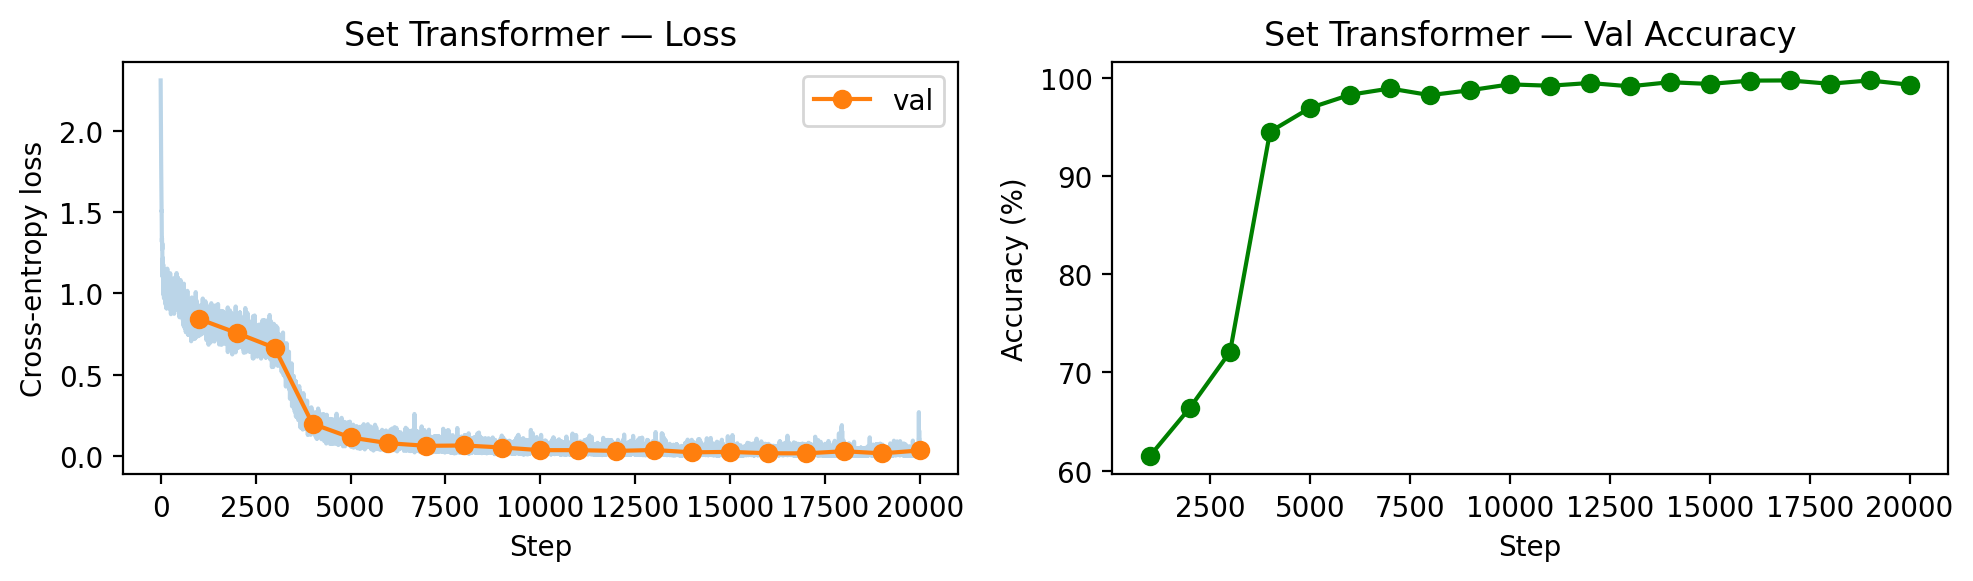

CPU times: user 56.4 s, sys: 10.8 s, total: 1min 7s
Wall time: 50.7 s


  step  3000 | train loss=0.8177 | val loss=0.7599 | val acc=0.668


  step  4000 | train loss=0.7230 | val loss=0.7160 | val acc=0.692


  step  5000 | train loss=0.5564 | val loss=0.6554 | val acc=0.727


  step  6000 | train loss=0.6272 | val loss=0.6194 | val acc=0.744


  step  7000 | train loss=0.5578 | val loss=0.5885 | val acc=0.756


  step  8000 | train loss=0.4801 | val loss=0.5261 | val acc=0.788


  step  9000 | train loss=0.3935 | val loss=0.3654 | val acc=0.858


  step 10000 | train loss=0.0626 | val loss=0.1105 | val acc=0.975


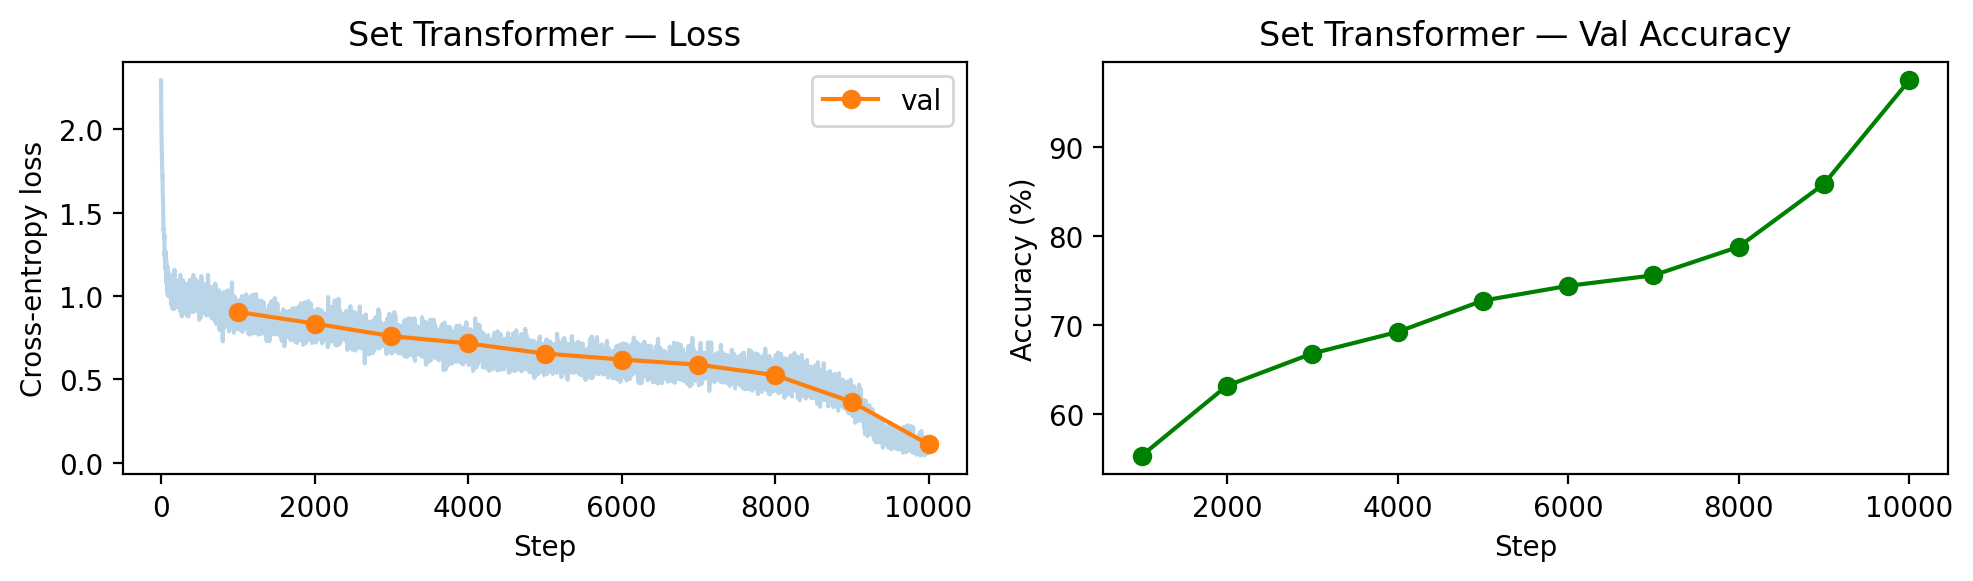

CPU times: user 27.9 s, sys: 3.81 s, total: 31.7 s
Wall time: 24 s


In [59]:
%%time
st_params, st_losses, st_val = train('Set Transformer', init_set_transformer, set_transformer, n_steps=20_000)
plot_training('Set Transformer', st_losses, st_val)

In [60]:
pred_orig = jnp.argmax(set_transformer(st_params, x_orig), axis=-1)
pred_perm = jnp.argmax(set_transformer(st_params, x_perm), axis=-1)
changed = float(jnp.mean(pred_orig != pred_perm))
print(f"Set Transformer: {100 * changed:.1f}% of predictions changed after permuting card order")

Set Transformer: 0.0% of predictions changed after permuting card order


# Comparison

We compare all three models on the same train/val/test split: parameter count, training dynamics, and test accuracy.

In [62]:
results = []
for name, params, model in [
    ('Flattened MLP', mlp_params, mlp),
    ('Deep Sets', ds_params, deep_sets),
    ('Set Transformer', st_params, set_transformer),
]:
    n_p = count_params(params)
    train_acc = accuracy(params, model, X_train[:10000], Y_train[:10000])
    val_acc = accuracy(params, model, X_val, Y_val)
    test_acc = accuracy(params, model, X_test, Y_test)
    results.append((name, n_p, train_acc, val_acc, test_acc))

print(f"{'Model':<20s} {'Params':>8s} {'Train':>8s} {'Val':>8s} {'Test':>8s}")
print("-" * 55)
for name, n_p, tr, va, te in results:
    print(f"{name:<20s} {n_p:>8,d} {100 * tr:>7.1f}% {100 * va:>7.1f}% {100 * te:>7.1f}%")

Model                  Params    Train      Val     Test
-------------------------------------------------------
Flattened MLP           5,210    99.7%    99.6%    99.6%
Deep Sets               5,202    93.2%    93.0%    92.9%
Set Transformer         5,198    99.3%    99.3%    99.3%


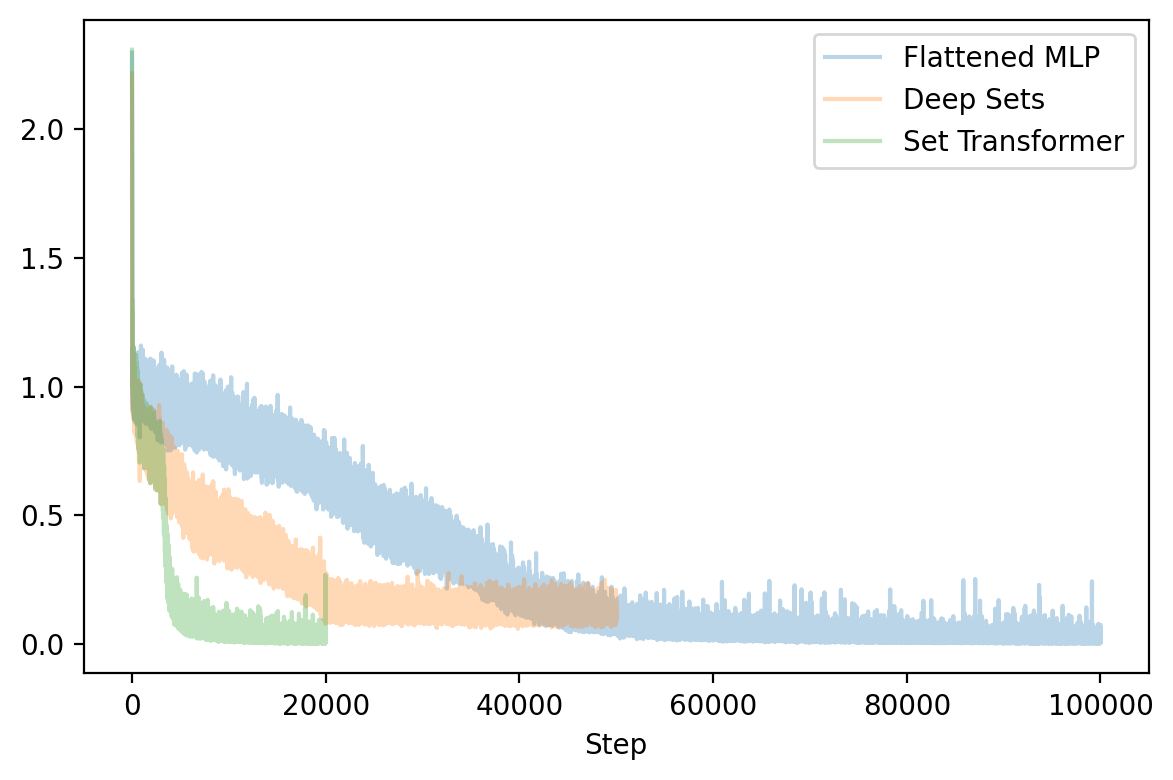

In [64]:
fig, ax = plt.subplots(1, 1, figsize=(6, 4))

for name, losses, val_log in [
    ('Flattened MLP', mlp_losses, mlp_val),
    ('Deep Sets', ds_losses, ds_val),
    ('Set Transformer', st_losses, st_val)]:
    ax.plot(losses, alpha=0.3, label=name)
    if val_log:
        steps, vl, va = zip(*val_log)
        axes[0].plot(steps, vl, 'o-', markersize=3)
ax.set_xlabel('Step'); axes[0].set_ylabel('Cross-entropy loss')
ax.legend(); axes[0].set_title('Training loss')

plt.tight_layout(); plt.show()

## Discussion

### What each architecture buys us

| Property | Flattened MLP | Deep Sets | Set Transformer |
|----------|:---:|:---:|:---:|
| Permutation invariant | ✗ | ✓ | ✓ |
| Variable-size input | ✗ | ✓ | ✓ |
| Inter-element interactions before pooling | ✗ | ✗ | ✓ |

- **Flattened MLP** is a useful baseline but has the wrong symmetry for sets. It must learn approximate invariance from data, wasting capacity and compute. It also cannot generalise to different set sizes.

- **Deep Sets** provides the simplest correct symmetry for unordered inputs. For poker hands, where the class depends on counting how many cards share a rank or suit, sum pooling is a natural fit — it directly computes aggregate statistics. The theoretical result of Zaheer et al. guarantees that this architecture can represent *any* permutation-invariant function.

- **Set Transformer** adds self-attention before pooling, enabling content-dependent inter-card interactions. For example, attention can directly compare whether two cards share a suit (for flush detection) or have consecutive ranks (for straight detection), before the information is pooled into a single vector.

### Bridge to sequence models

In this notebook, the input is a **set** (unordered), so:
- No positional encoding is needed
- No causal masking is needed
- Permutation invariance is desired

In the sequence model notebooks ([RNN](RNN.ipynb), [GRU](GRU.ipynb), [text transformer](test-transformer.ipynb), [nanochat](nanochat.ipynb)), the input is a **sequence** (ordered), so:
- **Positional encoding** injects order information,
- **Causal masking** prevents attending to future tokens when the task is to predict them
- The model should be **permutation-sensitive** — "cat sat on mat" ≠ "mat sat on cat"

The attention mechanism is the same in both cases. The difference is entirely in what structural assumptions we add on top of it.

## References

1. **Zaheer et al. (2017)** Deep Sets. *NeurIPS*. [arXiv:1703.06114](https://arxiv.org/abs/1703.06114)
2. **Lee et al. (2019)** Set Transformer: A Framework for Attention-based Permutation-Invariant Input. *ICML*. [arXiv:1810.00825](https://arxiv.org/abs/1810.00825)
3. **Vaswani et al. (2017)** Attention Is All You Need. *NeurIPS*. [arXiv:1706.03762](https://arxiv.org/abs/1706.03762)
4. **Poker Hand dataset.** UCI Machine Learning Repository. [Link](https://archive.ics.uci.edu/dataset/158/poker+hand)

# Colophon
This notebook was written by [Yoav Ram](http://python.yoavram.com).

This work is licensed under a [CC BY-SA 4.0](https://creativecommons.org/licenses/by-sa/4.0/) International License.

![Python logo](https://www.python.org/static/community_logos/python-logo.png)